# Análisis Exploratorio de Datos (EDA) sobre Mortalidad en Medellín (2012-2023)
Camilo Gonzalez y Rubén Esguerra
## Introducción

El estudio de la mortalidad en una población es fundamental para comprender los patrones de salud, identificar grupos de riesgo y orientar la formulación de políticas públicas. En la ciudad de Medellín, el registro de defunciones es gestionado por las Instituciones Prestadoras de Servicios de Salud (IPS), las cuales recopilan información de carácter demográfico, geográfico, temporal y clínico asociada a cada fallecimiento.

El presente proyecto tiene como propósito desarrollar un Análisis Exploratorio de Datos (EDA) sobre el conjunto de datos de mortalidad en Medellín, el cual contiene aproximadamente 145.000 registros correspondientes al período 2012–2023. Esta información es suministrada por la Secretaría de Salud a través de la plataforma de datos abiertos MeData.

Adicionalmente, este análisis servirá como base para la construcción de dashboards interactivos en herramientas como Dash (Python) y Shiny (R), facilitando la visualización de los hallazgos y su interpretación por parte de tomadores de decisiones.

---

## Problema 
A pesar de que el sistema de registro de defunciones en Medellín recopila una amplia variedad de variables —incluyendo aspectos demográficos, geográficos, socioeconómicos, temporales y relacionados con la causa de muerte—, la magnitud y complejidad del dataset dificultan la identificación rápida de patrones relevantes.

Entre las principales dificultades se encuentran:

- Identificación de tendencias y comportamientos temporales en las defunciones
- Análisis de diferencias territoriales entre comunas y barrios
- Caracterización de la población según variables como sexo, edad y nivel educativo
- Presencia de valores faltantes o inconsistentes que afectan la calidad del análisis

Además, algunas variables presentan codificaciones específicas que requieren transformación previa para su correcta interpretación, como es el caso de la variable `EDAD` en su formato original.

En este contexto, resulta necesario aplicar un proceso sistemático de exploración y depuración de los datos que permita comprender su estructura, mejorar su calidad y facilitar la extracción de información relevante.

---

## Objetivo

**Objetivo general:**
Realizar un Análisis Exploratorio de Datos (EDA) sobre el conjunto de información de mortalidad en Medellín entre 2012 y 2023, con el fin de identificar patrones relevantes y preparar los datos para la construcción de visualizaciones interactivas y modelos predictivos.

**Objetivos específicos:**

- Describir la estructura del dataset, incluyendo tipos de variables, valores nulos y posibles duplicados
- Analizar la distribución de la variable objetivo `NOM_667_OPS_GRUPO`
- Caracterizar el perfil sociodemográfico de los fallecidos (sexo, edad, estado civil y nivel educativo)
- Explorar la evolución temporal de las defunciones por año y mes
- Analizar la distribución geográfica de las defunciones por comuna y barrio
- Identificar relaciones entre la variable objetivo y otras variables relevantes mediante análisis bivariado
- Seleccionar variables útiles para la construcción de un modelo de clasificación

---

##  Descripción del Dataset

| Atributo | Detalle |
|---------|--------|
| **Fuente** | MeData — Alcaldía de Medellín / Secretaría de Salud |
| **URL** | https://medata.gov.co/node/16570 |
| **Período** | 2012 – 2023 |
| **Registros** | ~145.000 defunciones |
| **Variables** | 26 columnas |
| **Última actualización** | Septiembre 2023 |
| **Licencia** | Creative Commons CC BY-SA 4.0 |
| **Ruta local** | `D:/Descargas/defunciones.csv` |

Este conjunto de datos contiene información detallada sobre las defunciones registradas en Medellín, incluyendo variables relacionadas con las características de los individuos, su ubicación, condiciones sociales y causas de muerte. La variable de interés principal corresponde a NOM_667_OPS_GRUPO, la cual agrupa las causas de muerte según la clasificación OPS

---

## Carga y vista preeliminar del dataset

A continuación se presentan las principales características del conjunto de datos de defunciones, con el fin de comprender su estructura, tipo de variables y calidad de la información antes de realizar el análisis exploratorio.

In [545]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)

In [546]:
df_raw = pd.read_csv("defunciones.csv", low_memory=False)
print(f"Shape original: {df_raw.shape}")

Shape original: (145377, 26)


El dataset contiene 145,377 registros y 26 variables. Se trata de un volumen de datos considerable, suficiente para realizar análisis exploratorios robustos y construir modelos predictivos sin problemas de tamaño muestral.

## Vista inicial de los datos

In [547]:
df_raw.head().T

,0,1,2,3,4
NUM_FORMUL,1,2,3,4,5
COD_INST,NaN,050010214401,050010590901,NaN,NaN
NOM_INST,NaN,EMPRESA SOCIAL DEL ESTADO HOSPITAL GENERAL DE ...,IPS UNIVERSIDA DE ANTIOQUIA IPS UNIVERSITARIA,NaN,NaN
TIPO_DEFUN,2,2,2,2,2
FECHA_DEF,02/01/2012,02/01/2012,02/01/2012,02/01/2012,02/01/2012
ANO,2012,2012,2012,2012,2012
MES,1,1,1,1,1
SEXO,1,1,1,1,1
EST_CIVIL,9,5,9,9,9
EDAD,4051,4026,4065,4029,4032


Se observa la estructura general del dataset, incluyendo variables demográficas, geográficas, temporales y de causa de muerte. Se identifican valores faltantes en columnas como COD_INST y NOM_INST, así como la presencia de valores categóricos como "Sin informacion", que requerirán tratamiento posterior

## Información general del dataset

In [548]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145377 entries, 0 to 145376
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   NUM_FORMUL         145377 non-null  int64  
 1   COD_INST           133469 non-null  object 
 2   NOM_INST           133629 non-null  object 
 3   TIPO_DEFUN         145377 non-null  int64  
 4   FECHA_DEF          145377 non-null  object 
 5   ANO                145377 non-null  int64  
 6   MES                145377 non-null  int64  
 7   SEXO               145377 non-null  int64  
 8   EST_CIVIL          145377 non-null  int64  
 9   EDAD               145377 non-null  int64  
 10  NIVEL_EDU          145377 non-null  int64  
 11  CODPTORE           145377 non-null  int64  
 12  CODMUNRE           145377 non-null  int64  
 13  COD_BARRIRES       145377 non-null  object 
 14  SEG_SOCIAL         145377 non-null  int64  
 15  IDADMISALUD        139689 non-null  float64
 16  ID

La mayoría de las variables no presentan valores nulos, aunque algunas columnas administrativas (COD_INST, NOM_INST, IDADMISALUD, IDCODADMI, IDCLASADMI) tienen datos faltantes. Se identifican variables tipo object que representan categorías, y variables como FECHA_DEF que deberían convertirse a formato de fecha para facilitar el análisis temporal.

##  Estadísticas descriptivas

In [549]:
df_raw.describe()

,NUM_FORMUL,TIPO_DEFUN,ANO,MES,SEXO,EST_CIVIL,EDAD,NIVEL_EDU,CODPTORE,CODMUNRE,SEG_SOCIAL,IDADMISALUD
count,"145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","145,377.00","139,689.00"
mean,"72,689.00",2.00,"2,016.97",6.57,1.48,5.02,"4,039.33",26.15,5.00,1.00,1.65,1.64
std,"41,966.87",0.00,2.94,3.45,0.50,1.81,269.63,39.74,0.00,0.00,1.20,1.33
min,1.00,2.00,"2,012.00",1.00,1.00,1.00,1.00,1.00,5.00,1.00,1.00,1.00
25%,"36,345.00",2.00,"2,014.00",4.00,1.00,4.00,"4,058.00",2.00,5.00,1.00,1.00,1.00
50%,"72,689.00",2.00,"2,017.00",7.00,1.00,5.00,"4,073.00",3.00,5.00,1.00,1.00,1.00
75%,"109,033.00",2.00,"2,020.00",10.00,2.00,6.00,"4,084.00",13.00,5.00,1.00,2.00,2.00
max,"145,377.00",2.00,"2,021.00",12.00,3.00,9.00,"9,999.00",99.00,5.00,1.00,9.00,9.00


Las variables numéricas presentan rangos amplios, especialmente en EDAD, lo que sugiere que su codificación no es directa y requiere transformación. Además, variables categóricas codificadas como números (SEXO, EST_CIVIL, NIVEL_EDU) necesitan ser interpretadas según su diccionario de datos.

## Diccionario de variables

Se realiza una descripción de las variables del conjunto de datos de defunciones, utilizando la información de la documentación y dando contexto de qué representa cada variable.

- **NUM_FORMUL (Número consecutivo):** Corresponde a un número de orden único y secuencial asignado a cada registro de defunción dentro de la base de datos. Sirve como identificador único para diferenciar un caso de otro, facilitando la organización y referencia de los datos.

- **COD_INST (Identificador alfanumérico):** Código único que identifica la institución de salud (hospital, clínica, centro de salud) que reportó o donde ocurrió la defunción. Permite vincular el fallecimiento con el prestador de servicios de salud.

- **NOMB_INST (Categórica):** Nombre completo de la institución de salud correspondiente al código COD_INST. Ejemplos: "Hospital Universitario del Caribe", "Clínica La Misericordia".

- **TIPO_DEFUN (Categórica codificada):** Clasifica el tipo de defunción según las normas sanitarias. Puede ser:

    - **1 = Defunción Fetal:** Muerte de un producto de la concepción antes de su expulsión o extracción completa del cuerpo de la madre, independientemente de la duración del embarazo.

    - **2 = Defunción No Fetal:** Muerte de una persona que ha nacido con vida (independientemente de la edad).

- **FECHA_DEFUN (Serie temporal):** Fecha exacta en la que ocurrió el fallecimiento. Es el dato temporal más preciso para el evento. Su formato suele ser DD/MM/AAAA o similar.

- **ANO (Serie temporal - Año):** Año calendario en el que se produjo la defunción. Se extrae de FECHA_DEFUN y es útil para agrupar datos por años.

- **MES (Serie temporal - Mes):** Mes del año en el que se produjo la defunción. Complementa a ANO y FECHA_DEFUN para análisis estacionales o mensuales.

- **SEXO (Categórica codificada):** Sexo biológico de la persona fallecida, registrado según el certificado de defunción. Sus valores son:

    - **1 = Masculino**
    - **2 = Femenino**
    - **3 = Indeterminado** (usado en casos donde no fue posible determinar el sexo, comúnmente en defunciones fetales o neonatales).


- **EST_CIVIL (Categórica codificada):** Estado civil de la persona fallecida al momento de su muerte. Proporciona información sociodemográfica relevante.

    - **1 =** No estaba casado(a) y llevaba dos o más años viviendo con su pareja (Unión Libre estable)
    - **2 =** No estaba casado(a) y llevaba menos de dos años viviendo con su pareja (Unión Libre reciente)
    - **3 =** Estaba separado(a) o divorciado(a)
    - **4 =** Estaba viudo(a)
    - **5 =** Estaba soltero(a) (nunca se casó ni vivió en unión libre)
    - **6 =** Estaba casado(a)
    - **9 =** Sin información


- **EDAD (Categórica codificada como texto):** Variable compleja que codifica la edad al momento de la muerte con un formato especial de 4 dígitos. Es fundamental para estudios de mortalidad en todas las edades, especialmente en la primera infancia. Estructura:

    - **0000 a 0059:** Edad en minutos (ej: 0001 = 1 minuto)
    - **0099:** Menor de una hora, pero sin información de minutos exactos
    - **1001 a 1023:** Edad en horas (ej: 1005 = 5 horas)
    - **1099:** Menor de un día, pero sin información de horas exactas
    - **2001 a 2029:** Edad en días (ej: 2015 = 15 días de vida)
    - **2099:** Menor de un mes, pero sin información de días exactos
    - **3001 a 3011:** Edad en meses (ej: 3009 = 9 meses)
    - **3099:** Menor de un año, pero sin información de meses exactos
    - **4001 a 4098:** Edad en años (ej: 4030 = 30 años)
    - **4099:** 99 años
    - **4100 a 4120:** Edad de 100 a 120 años
    - **4999:** Mayor de un año, pero edad desconocida
    - **4000:** Mujer en edad fértil (generalmente 15-49 años), sin información de edad
    - **8888:** Sin información de edad
    - **9999:** Edad completamente desconocida


- **NIVEL_EDU (Categórica codificada):** Máximo nivel educativo alcanzado por la persona fallecida. Es un indicador socioeconómico clave.

    - **1 = Preescolar**
    - **2 = Básica primaria** (1º a 5º)
    - **3 = Básica secundaria** (6º a 9º)
    - **4 = Media académica o clásica** (10º y 11º)
    - **5 = Media técnica**
    - **6 = Normalista** (formación de docentes)
    - **7 = Técnica profesional**
    - **8 = Tecnológica**
    - **9 = Profesional** (universitaria)
    - **10 = Especialización**
    - **11 = Maestría**
    - **12 = Doctorado**
    - **13 = Ninguno**
    - **99 = Sin información**


- **CODPTORE (Identificador numérico):** Código numérico del departamento de residencia habitual del fallecido, según la División Político-Administrativa del DANE.

    - **01** = Sin información de departamento
    - **75** = Con residencia en el extranjero

- **CODMUNRE (Identificador numérico):** Código numérico del municipio de residencia habitual del fallecido. Complementa a CODPTORE.

    - **999 =** Sin información de municipio.

    - Para residentes en el extranjero, se usa el código del país.

- **CODBARRIRES (Identificador numérico):** Código numérico del barrio de residencia del fallecido. Permite un nivel de desagregación geográfico muy fino (nivel de barrio).

- **SEG_SOCIAL (Categórica codificada):** Régimen de afiliación al Sistema General de Seguridad Social en Salud (SGSSS) que tenía el fallecido.

    - **1 = Contributivo:** Para trabajadores formales y sus familias
    - **2 = Subsidiado:** Para población de bajos recursos
    - **3 = Excepción:** Poblaciones especiales (jubilados, fuerzas militares, etc.)
    - **4 = Especial:** Comunidades indígenas, magisterio, etc.
    - **5 = No asegurado:** Sin afiliación a salud


- **IDADMISALU (Categórica codificada):** Tipo de Entidad Administradora de salud a la que pertenecía el fallecido.

    - **1 = Entidad Promotora de Salud (EPS)** del régimen contributivo
    - **2 = EPS** del régimen subsidiado
    - **3 = Entidad Adaptada de Salud** (antiguas cajas de previsión)
    - **4 = Entidad Especial de Salud** (indígenas, etc.)
    - **5 = Entidad Exceptuada de Salud** (Fuerzas Militares, Policía Nacional)
    - **9 = Sin información**

- **IDCODADMI (Identificador numérico):** Código único oficial que identifica a la administradora de salud (EPS, ARS, etc.) a la que estaba afiliado el fallecido.

- **IDCLASADMI (Categórica):** Nombre comercial o razón social de la entidad administradora de salud (ej. "Nueva EPS", "Salud Total", "Savia Salud").

- **N_BAS1 (Categórica - Texto):** Descripción textual, en lenguaje natural, de la causa básica de defunción. Esta es la enfermedad o lesión que inició la cadena de eventos que llevaron directamente a la muerte (ej. "Infarto agudo de miocardio", "Accidente de tránsito").

- **C_BAS1 (Categórica - Código):** Código alfanumérico de la causa básica de defunción según la Clasificación Internacional de Enfermedades, versión 10 (CIE-10). Es la versión estandarizada del código. Por ejemplo: I21 para "Infarto agudo de miocardio".

- **BARRIO_RES (Categórica):** Nombre del barrio de residencia habitual del fallecido. Es la versión textual del código CODBARRIRES. Ejemplo: "El Prado", "Las Américas".

- **COMUNA_RES (Categórica):** Nombre o número de la comuna (división administrativa urbana que agrupa varios barrios) donde residía el fallecido. Útil para análisis urbanos.

- **ETAREO_QUIN (Categórica):** Grupo de edad quinquenal al que pertenece el fallecido. Es una categorización de EDAD_SIMPLE para análisis demográficos estandarizados. Ejemplo: "00-04 años", "05-09 años", "80 y más".

- **EDAD_SIMPLE (Numérica discreta):** Edad puntual del fallecido en años cumplidos. A diferencia de EDAD, esta variable es numérica simple y continua (ej: 25, 0, 102). Es la más práctica para cálculos estadísticos y gráficos.

- **NOM_6/67_OPS_GRUPO (Categórica):** Nombre del grupo de causas de muerte según la lista reducida de tabulación "6/67" de la Organización Panamericana de la Salud (OPS). Agrupa códigos CIE-10 en categorías amplias. Ejemplo: "Enfermedades del sistema circulatorio".

- **NOM_6/67_OPS_SUBC (Categórica):** Nombre de la subcategoría dentro de la lista "6/67 OPS". Es un nivel más detallado que el grupo, pero sigue siendo una agrupación de causas. Ejemplo: "Enfermedades isquémicas del corazón" (que pertenece al grupo de "Enfermedades del sistema circulatorio").

## Selección de variables para el análisis

Una vez revisado el diccionario de variables y la estructura del dataset, se realiza una selección de aquellas variables que realmente aportan al análisis de la variable objetivo NOM_667_OPS_GRUPO.

El objetivo de este paso es trabajar con un conjunto de datos más limpio y enfocado, evitando incluir información redundante o que no aporte al entendimiento de las causas de muerte.

Adicionalmente, se identifican variables que contienen la misma información en diferentes formatos. En estos casos, se selecciona la versión más adecuada para el análisis, priorizando claridad y facilidad de interpretación.

## Variables descartadas

A continuación, se presentan las variables que no serán utilizadas en el análisis, junto con la justificación correspondiente:

- ``NUM_FORMUL``: corresponde a un identificador único de cada registro, por lo que no aporta información relevante para el análisis.
- ``COD_INST``, ``NOM_INST``: hacen referencia a la institución que reporta el caso. Aunque son útiles a nivel administrativo, no aportan directamente al análisis de las causas de muerte.
- ``IDADMISALUD``, ``IDCODADMI``, ``IDCLASADMI``: variables relacionadas con la administración del sistema de salud. Su utilidad es principalmente operativa, por lo que no son relevantes para este estudio.
- ``C_BAS1``, ``N_BAS1``: contienen el código y la descripción específica de la causa de muerte según CIE-10. Sin embargo, la variable objetivo (``NOM_667_OPS_GRUPO``) se construye a partir de esta información, por lo que incluirlas en el análisis sería redundante y podría sesgar los resultados.
- ``NOM_667_OPS_SUBC``: representa una subclasificación más detallada de la variable objetivo, por lo que incluirla implicaría trabajar con información muy similar a la variable que se desea analizar.
- ``CODPTORE``: variable asociada a pertenencia étnica, la cual presenta una alta cantidad de valores faltantes y no aporta significativamente al objetivo del análisis.
- ``COD_BARRIRES``: código numérico del barrio que resulta redundante, ya que se cuenta con la variable BARRIO_RES en formato descriptivo.
- ``EDAD``: aunque contiene información detallada sobre la edad, su formato codificado requiere transformaciones adicionales. Dado que se dispone de la variable ``EDAD_SIMPLE``, que ya expresa la edad en años de forma directa, se decide utilizar esta última y descartar EDAD para evitar redundancia.

## Variables seleccionadas para el análisis

Las siguientes variables se consideran relevantes para el análisis, ya que permiten caracterizar las defunciones desde diferentes dimensiones:
| Variable            | Tipo              | Observaciones                                                     |
| ------------------- | ----------------- | --------------------------------------------------------------    |
| `NOM_667_OPS_GRUPO` | Variable objetivo | Se analizará su distribución y relación con otras variables       |
| `ANO`, `MES`        | Temporales        | Permiten analizar tendencias en el tiempo                         |
| `FECHA_DEF`         | Temporal          | Se utiliza para el manejo y validación de la información temporal |
| `SEXO`              | Demográfica       | Requiere recodificación para facilitar su interpretación          |
| `EDAD_SIMPLE`       | Demográfica       | Se utilizará como medida principal de edad                        |
| `ETAREO_QUIN`       | Demográfica       | Agrupación por rangos de edad                                     |
| `EST_CIVIL`         | Demográfica       | Requiere recodificación                                           |
| `NIVEL_EDU`         | Socioeconómica    | Puede agruparse para simplificar el análisis                      |
| `SEG_SOCIAL`        | Socioeconómica    | Requiere interpretación de categorías                             |
| `TIPO_DEFUN`        | Clasificatoria    | Permite diferenciar tipos de defunción                            |
| `COMUNA_RES`        | Geográfica        | Útil para análisis territorial                                    |
| `BARRIO_RES`        | Geográfica        | Nivel de detalle más específico, útil para visualización          |

### Descartar columnas irrelevantes

In [550]:
# Columnas a descartar
DROP_COLS = [
    "NUM_FORMUL",
    "COD_INST",
    "NOM_INST",
    "IDADMISALUD",
    "IDCODADMI",
    "IDCLASADMI",
    "C_BAS1",
    "N_BAS1",
    "NOM_667_OPS_SUBC",
    "CODPTORE",
    "COD_BARRIRES",
    "EDAD"
]

drop_existing = [c for c in DROP_COLS if c in df_raw.columns]
df = df_raw.drop(columns=drop_existing).copy()

print(f"Columnas originales : {df_raw.shape[1]}")
print(f"Columnas descartadas: {len(drop_existing)}")
print(f"Columnas retenidas  : {df.shape[1]}")
print(f"\nColumnas finales: {list(df.columns)}")

Columnas originales : 26
Columnas descartadas: 12
Columnas retenidas  : 14

Columnas finales: ['TIPO_DEFUN', 'FECHA_DEF', 'ANO', 'MES', 'SEXO', 'EST_CIVIL', 'NIVEL_EDU', 'CODMUNRE', 'SEG_SOCIAL', 'BARRIO_RES', 'COMUNA_RES', 'ETAREO_QUIN', 'EDAD_SIMPLE', 'NOM_667_OPS_GRUPO']


### Tratamiento de la variable ``ETAREO_QUIN``

La variable ``ETAREO_QUIN`` representa la edad agrupada en intervalos de cinco años. Aunque esta información puede derivarse a partir de ``EDAD_SIMPLE``, se decide conservarla ya que facilita el análisis categórico y la construcción de visualizaciones, especialmente en etapas posteriores como el desarrollo de dashboards. Así que se decide hacer un análisis de dicha variable.


In [551]:
df["ETAREO_QUIN"].value_counts(dropna=False)

ETAREO_QUIN
80-84                         17927
85-89                         17052
75-79                         16206
70-74                         14462
65-69                         12820
90-94                         11404
60-64                         10919
55-59                          8546
50-54                          6032
95-99                          4831
45-49                          4063
30-34                          3014
25-29                          3008
40-44                          2992
35-39                          2901
20-24                          2841
< 1 año                        2162
15-19                          1809
100 y mas                      1256
10-14                           356
1-4                             332
5-9                             223
oct-14                           77
1-abr                            53
5-sep                            52
Mayor de 2 años y sin inf.       25
Sin información                  11
Edad desconocida

La variable ``ETAREO_QUIN`` representa la edad agrupada en intervalos de cinco años. Inicialmente, se identificaron algunas categorías inconsistentes como ``oct-14``, ``1-abr`` y ``5-sep``, las cuales no corresponden a rangos válidos de edad.

In [552]:
df[["EDAD_SIMPLE", "ETAREO_QUIN"]].sample(10)

,EDAD_SIMPLE,ETAREO_QUIN
122181,77,75-79
66260,73,70-74
86838,65,65-69
51620,46,45-49
77476,60,60-64
3858,62,60-64
136280,41,40-44
79687,19,15-19
140172,67,65-69
60599,40,40-44


Estas inconsistencias se originan probablemente por errores de interpretación de formato (por ejemplo, conversión automática a fechas). Sin embargo, al contrastarlas con la variable ``EDAD_SIMPLE``, se observa que corresponden realmente a los rangos ``10-14``, ``1-4`` y ``5-9``, respectivamente.

Por esta razón, se realiza una corrección directa de estos valores en lugar de eliminarlos, conservando así la información de los registros.

In [553]:
df["ETAREO_QUIN"] = df["ETAREO_QUIN"].replace({
    "oct-14": "10-14",
    "1-abr": "1-4",
    "5-sep": "5-9"
})


Adicionalmente, categorías como "Sin información", "Edad desconocida" y "Mayor de 2 años y sin inf." se tratan como valores faltantes, ya que no aportan información útil para el análisis.


In [554]:
df.loc[df["ETAREO_QUIN"].isin([
    "Sin información",
    "Edad desconocida",
    "Mayor de 2 años y sin inf."
]), "ETAREO_QUIN"] = np.nan

In [555]:
df["ETAREO_QUIN"].value_counts().sort_index()

ETAREO_QUIN
1-4            385
10-14          433
100 y mas     1256
15-19         1809
20-24         2841
25-29         3008
30-34         3014
35-39         2901
40-44         2992
45-49         4063
5-9            275
50-54         6032
55-59         8546
60-64        10919
65-69        12820
70-74        14462
75-79        16206
80-84        17927
85-89        17052
90-94        11404
95-99         4831
< 1 año       2162
Name: count, dtype: int64

Finalmente, la variable presenta una distribución coherente y consistente con la edad numérica, por lo que se considera adecuada para su uso en el análisis exploratorio y visualización.

### Tratamiento de la variable ``EDAD_SIMPLE``

In [556]:
df["EDAD_SIMPLE"] = pd.to_numeric(df["EDAD_SIMPLE"], errors="coerce")

In [557]:
df["EDAD_SIMPLE"].describe()

count   145,350.00
mean         69.04
std          82.94
min           0.00
25%          58.00
50%          73.00
75%          84.00
max       8,888.00
Name: EDAD_SIMPLE, dtype: float64

Aunque la variable ``EDAD_SIMPLE`` facilita el análisis al estar expresada en años, se identificaron valores atípicos como 8888 y 4000, los cuales corresponden a edades desconocidas. Por esta razón, estos registros se tratan como valores faltantes.

In [558]:
df["EDAD_SIMPLE"] = pd.to_numeric(df["EDAD_SIMPLE"], errors="coerce")

df.loc[df["EDAD_SIMPLE"].isin([8888, 4000, 4999]), "EDAD_SIMPLE"] = np.nan
df["EDAD_SIMPLE"].describe()


count   145,338.00
mean         68.31
std          21.39
min           0.00
25%          58.00
50%          73.00
75%          84.00
max         116.00
Name: EDAD_SIMPLE, dtype: float64

In [559]:
faltantes = df["EDAD_SIMPLE"].isna().sum()
print(f"Faltantes: {faltantes} | Proporción: {faltantes / len(df) * 100:.2f}%")

Faltantes: 39 | Proporción: 0.03%


Luego del proceso de limpieza, la variable ``EDAD_SIMPLE`` presenta valores coherentes dentro del rango esperado (0 a 120 años), con una baja proporción de datos faltantes (0,02%) y sin presencia de valores atípicos que distorsionen el análisis.

Dado que ``EDAD_SIMPLE`` representa la edad de forma directa y precisa, se mantiene como la variable principal para el análisis de edad dentro del dataset.

### Conversión de fecha

La variable ``FECHA_DEF`` se encuentra inicialmente en formato de texto, por lo que es necesario convertirla a un formato de tipo fecha (``datetime``) para facilitar su análisis.

Esta transformación permite trabajar con la información temporal de manera más adecuada, especialmente para identificar rangos de tiempo, tendencias y posibles patrones en las defunciones.

Adicionalmente, se realiza una verificación del proceso de conversión, con el fin de asegurar que todas las fechas sean válidas y coherentes con el período del dataset.

In [560]:
df["FECHA_DEF"] = pd.to_datetime(df["FECHA_DEF"], dayfirst=True, errors="coerce")

# Verificar coherencia con ANO/MES ya presentes en el dataset
fecha_ok = df["FECHA_DEF"].notna().sum()
print(f"Fechas parseadas correctamente: {fecha_ok:,} / {len(df):,}")
print(f"Rango: {df['FECHA_DEF'].min().date()} → {df['FECHA_DEF'].max().date()}")

Fechas parseadas correctamente: 145,377 / 145,377
Rango: 2012-01-01 → 2021-12-31


Los resultados muestran que la totalidad de las fechas fueron convertidas correctamente, con un rango que abarca desde 2012 hasta 2021, lo cual es consistente con la información general del dataset.

### Recodificación de variables categóricas

Recodificación de variables categóricas

Algunas variables del dataset se encuentran codificadas numéricamente, lo que dificulta su interpretación directa. Por esta razón, se realiza un proceso de recodificación, asignando etiquetas descriptivas a cada categoría.

Este paso permite facilitar el análisis exploratorio y la construcción de visualizaciones, haciendo más comprensibles los resultados.

En particular, se recodifican las siguientes variables:

- ``SEXO``: se transforma de valores numéricos a categorías como masculino, femenino e indeterminado.
- ``TIPO_DEFUN``: permite diferenciar entre defunciones naturales, no naturales y en estudio.
- ``EST_CIVIL``: se agrupan algunas categorías similares (como tipos de unión libre) para simplificar el análisis.
- ``SEG_SOCIAL``: se traduce a los diferentes regímenes del sistema de salud.

Adicionalmente, la variable ``NIVEL_EDU`` se agrupa en categorías más amplias, con el fin de reducir la granularidad y facilitar la interpretación de los resultados.

In [561]:
# SEXO
df["SEXO"] = df["SEXO"].map({1: "Masculino", 2: "Femenino", 3: "Indeterminado"}).fillna("Sin info")

# TIPO_DEFUN
df["TIPO_DEFUN"] = df["TIPO_DEFUN"].map({1: "Fetal", 2: "No fetal"}).fillna("Sin info")

# EST_CIVIL (codificación original: 1=UL estable, 2=UL reciente, 3=Sep/Div, 4=Viudo, 5=Soltero, 6=Casado, 9=Sin info)
est_map = {1: "Unión libre", 2: "Unión libre", 3: "Separado/a",
           4: "Viudo/a", 5: "Soltero/a", 6: "Casado/a", 9: "Sin info"}
df["EST_CIVIL"] = df["EST_CIVIL"].map(est_map).fillna("Sin info")

# SEG_SOCIAL
seg_map = {1: "Contributivo", 2: "Subsidiado", 3: "Vinculado",
           4: "Particular", 5: "Excepción", 6: "Indígena"}
df["SEG_SOCIAL"] = df["SEG_SOCIAL"].map(seg_map).fillna("Sin info")

# NIVEL_EDU — agrupado en niveles relevantes para análisis
def agrupar_nivel_educativo(x):
    if x in [1, 2]: return "Básica"
    elif x in [3, 4, 5]: return "Media"
    elif x in [6, 7, 8]: return "Técnico/Tecnológico"
    elif x in [9, 10, 11, 12]: return "Superior"
    else: return "Sin info"

df["NIVEL_EDU_GRUPO"] = df["NIVEL_EDU"].apply(agrupar_nivel_educativo)

print("Recodificaciones completadas.")
print("\nDistribución SEXO:")
print(df["SEXO"].value_counts())

Recodificaciones completadas.

Distribución SEXO:
SEXO
Masculino        76224
Femenino         69150
Indeterminado        3
Name: count, dtype: int64


### Limpieza de la variable objetivo

La variable ``NOM_667_OPS_GRUPO`` corresponde a la clasificación de la causa de muerte y es el eje central del análisis.

In [562]:
# Limpieza básica de texto
df["NOM_667_OPS_GRUPO"] = df["NOM_667_OPS_GRUPO"].str.strip()

print(df["NOM_667_OPS_GRUPO"].value_counts(dropna=False))

NOM_667_OPS_GRUPO
Enfermedades del sistema circulatorio                    41337
Neoplasias (Tumores)                                     34857
Todas las demas enfermedades                             33785
Enfermedades Transmisibles                               19070
Causas externas                                          14462
Ciertas afecciones originadas en el periodo perinatal     1121
Signos sintomas y afecciones mal definidas                 519
Signos, sintomas y afecciones mal definidas                226
Name: count, dtype: int64


Al revisar sus valores, no se identificaron datos faltantes ni registros sin información. Sin embargo, se detectaron inconsistencias en la escritura de algunas categorías, específicamente diferencias en el uso de signos de puntuación.

Para corregir esto, se realiza una limpieza básica del texto, eliminando caracteres como comas y espacios innecesarios, con el fin de unificar categorías equivalentes.

In [563]:
# Unificar categorías inconsistentes
df["NOM_667_OPS_GRUPO"] = df["NOM_667_OPS_GRUPO"].str.replace(",", "", regex=False)

# Verificación
print(df["NOM_667_OPS_GRUPO"].value_counts())

NOM_667_OPS_GRUPO
Enfermedades del sistema circulatorio                    41337
Neoplasias (Tumores)                                     34857
Todas las demas enfermedades                             33785
Enfermedades Transmisibles                               19070
Causas externas                                          14462
Ciertas afecciones originadas en el periodo perinatal     1121
Signos sintomas y afecciones mal definidas                 745
Name: count, dtype: int64


### Ajustes finales del dataset

In [564]:
# Partimos del dataset ya trabajado
df_clean = df.copy()

# Eliminar variable sin variabilidad
df_clean.drop(columns=["TIPO_DEFUN"], inplace=True)

# Verificación rápida
print(f"Dataset final: {df_clean.shape[0]:,} registros × {df_clean.shape[1]} variables")
print("\nColumnas:")
print(df_clean.columns.tolist())

print("\nVerificación de nulos:")
print((df_clean.isna().mean()*100).round(2))

Dataset final: 145,377 registros × 14 variables

Columnas:
['FECHA_DEF', 'ANO', 'MES', 'SEXO', 'EST_CIVIL', 'NIVEL_EDU', 'CODMUNRE', 'SEG_SOCIAL', 'BARRIO_RES', 'COMUNA_RES', 'ETAREO_QUIN', 'EDAD_SIMPLE', 'NOM_667_OPS_GRUPO', 'NIVEL_EDU_GRUPO']

Verificación de nulos:
FECHA_DEF           0.00
ANO                 0.00
MES                 0.00
SEXO                0.00
EST_CIVIL           0.00
NIVEL_EDU           0.00
CODMUNRE            0.00
SEG_SOCIAL          0.00
BARRIO_RES          0.00
COMUNA_RES          0.00
ETAREO_QUIN         0.03
EDAD_SIMPLE         0.03
NOM_667_OPS_GRUPO   0.00
NIVEL_EDU_GRUPO     0.00
dtype: float64


Una vez realizadas las transformaciones y limpieza de las variables, se procede a una revisión final del conjunto de datos con el fin de asegurar su coherencia antes del análisis exploratorio.

En este paso, se identifica que la variable ``TIPO_DEFUN`` presenta un único valor en todos los registros (defunciones no fetales), por lo que no aporta información relevante para el análisis. Debido a esto, se decide eliminarla del dataset, ya que no permite establecer comparaciones ni identificar patrones.

Adicionalmente, se verifica la ausencia de valores faltantes en las variables seleccionadas, lo que permite trabajar con un conjunto de datos completo y consistente.

Como resultado, se obtiene un dataset limpio, con variables relevantes y listo para el análisis exploratorio.

---

## Análisis univariado


### Grupo OPS

Se inicia el análisis exploratorio estudiando la distribución de la variable objetivo `NOM_667_OPS_GRUPO`, ya que esta permite identificar cuáles son las principales causas de muerte en el dataset.

Este análisis es importante porque:
- Permite detectar si existen clases dominantes
- Ayuda a entender el comportamiento general de la mortalidad
- Sirve como base para los análisis posteriores

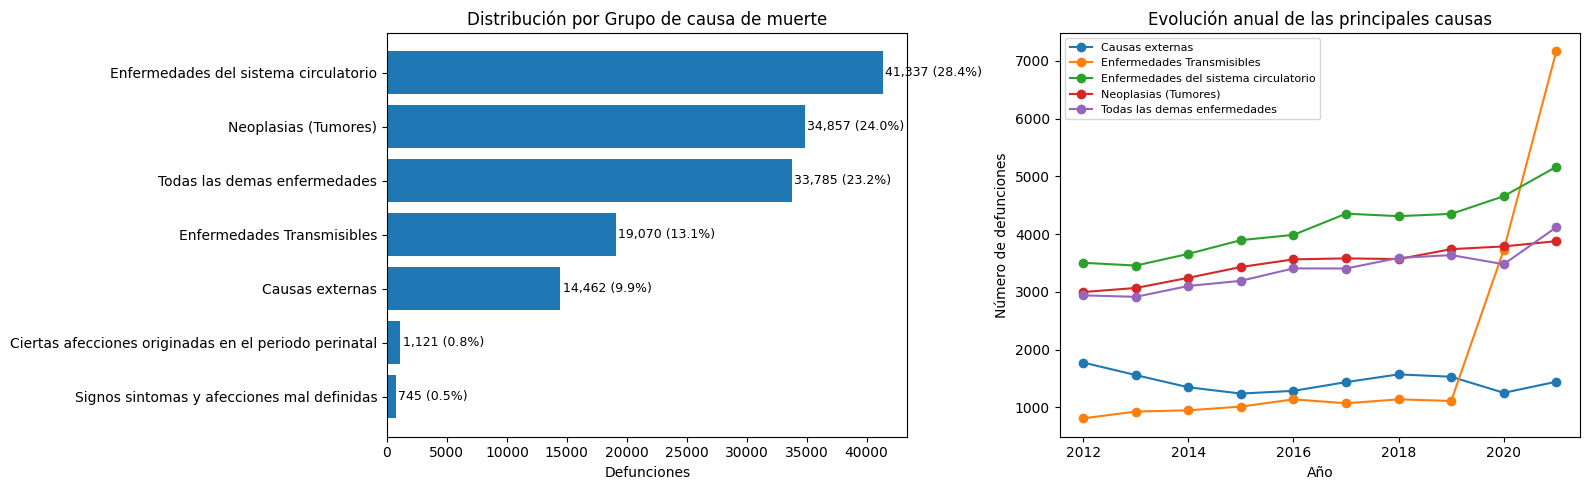

In [565]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vo_counts = df_clean["NOM_667_OPS_GRUPO"].value_counts()
vo_pct    = (vo_counts / len(df_clean) * 100).round(1)

# Gráfico de barras
axes[0].barh(vo_counts.index, vo_counts.values)
for i, (v, p) in enumerate(zip(vo_counts.values, vo_pct.values)):
    axes[0].text(v + 200, i, f"{v:,} ({p}%)", va="center", fontsize=9)

axes[0].set_xlabel("Defunciones")
axes[0].set_title("Distribución por Grupo de causa de muerte")
axes[0].invert_yaxis()

# Evolución temporal (top 5)
top5 = vo_counts.head(5).index
df_top5 = df_clean[df_clean["NOM_667_OPS_GRUPO"].isin(top5)]

evol = df_top5.groupby(["ANO", "NOM_667_OPS_GRUPO"]).size().unstack(fill_value=0)

for col in evol.columns:
    axes[1].plot(evol.index, evol[col], marker="o", label=col)

axes[1].set_title("Evolución anual de las principales causas")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Número de defunciones")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

A partir de la distribución de la variable objetivo, se observa que:

- Las principales causas de muerte corresponden a:
  - Enfermedades del sistema circulatorio (~28%)
  - Neoplasias (tumores) (~24%)
  - Otras enfermedades (~23%)

- Estas tres categorías concentran aproximadamente el 75% de las defunciones, lo que indica una alta concentración en causas crónicas no transmisibles.

- Las enfermedades transmisibles representan una menor proporción (~13%), mientras que las causas externas (accidentes, violencia, etc.) tienen una participación cercana al 10%.

- Las categorías menos frecuentes, como afecciones perinatales o causas mal definidas, tienen una presencia marginal en el dataset.

En cuanto a la evolución temporal:

  - Las enfermedades del sistema circulatorio muestran un leve aumento progresivo con cada periodo, reflejando una tendencia ascendente en este tipo de afecciones a lo largo de los años.
  - En 2019, se observa un pico abismal notable en las enfermedades transmisibles, especialmente a raíz de la pandemia de COVID-19, lo que genera una alteración significativa en el patrón de mortalidad.
  - Las principales causas de muerte muestran, en general, una tendencia estable, aunque con variaciones notables durante los años de impacto pandémico.

En general, estos resultados son consistentes con lo esperado en poblaciones urbanas, donde predominan las enfermedades crónicas, aunque con un cambio relevante en las enfermedades infecciosas debido a la crisis sanitaria global.

### Sexo

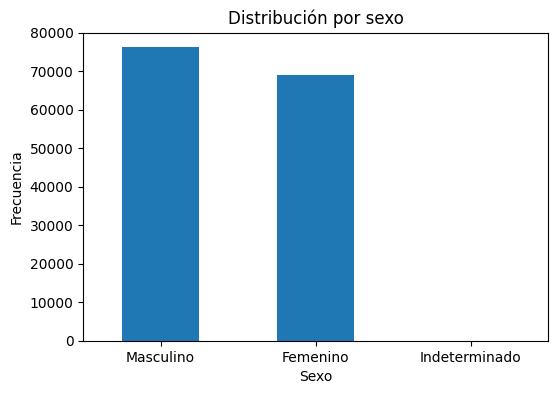

               Frecuencia     %
SEXO                           
Masculino           76224 52.40
Femenino            69150 47.60
Indeterminado           3  0.00


In [566]:
sexo_counts = df_clean["SEXO"].value_counts()
sexo_pct = (sexo_counts / len(df_clean) * 100).round(1)

plt.figure(figsize=(6,4))
sexo_counts.plot(kind="bar")
plt.title("Distribución por sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

print(pd.DataFrame({
    "Frecuencia": sexo_counts,
    "%": sexo_pct
}))

La variable ``SEXO`` presenta una distribución relativamente equilibrada:

- Masculino: ~52%
- Femenino: ~48%
- Indeterminado: casos mínimos

Esto indica que no existe un sesgo fuerte en la variable, lo cual es positivo para el análisis, ya que permite comparaciones más equilibradas entre ambos grupos.

Además, la baja presencia de valores indeterminados sugiere una buena calidad en el registro de esta variable.

###  Edad

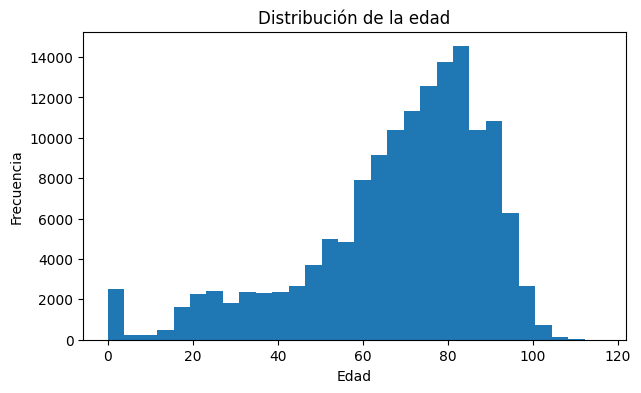

count   145,338.00
mean         68.30
std          21.40
min           0.00
25%          58.00
50%          73.00
75%          84.00
max         116.00
Name: EDAD_SIMPLE, dtype: float64


In [567]:
plt.figure(figsize=(7,4))
plt.hist(df_clean["EDAD_SIMPLE"], bins=30)
plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

print(df_clean["EDAD_SIMPLE"].describe().round(1))

La variable ``EDAD_SIMPLE`` presenta una distribución coherente con el fenómeno estudiado:

- La edad promedio es de aproximadamente 68 años
- La mediana se ubica en 73 años, lo que indica una concentración de defunciones en edades adultas mayores
- El 50% de los casos se encuentra entre los 58 y 84 años (rango intercuartílico)
- La edad máxima observada es de 116 años, dentro de los límites esperados del dataset

En general, la distribución muestra que la mayor parte de las defunciones ocurre en población de edad avanzada, lo cual es consistente con patrones demográficos habituales.

Adicionalmente, se observan edades cercanas a 0 años, asociadas a mortalidad en etapas tempranas de la vida, aunque representan una proporción menor dentro del total de registros.

## Análisis bivariado: `NOM_667_OPS_GRUPO` vs variables relevantes

El objetivo es identificar posibles patrones o diferencias en las causas de muerte según características demográficas, sociales y temporales, lo cual permite enriquecer la interpretación de los datos más allá del análisis individual de cada variable.

### 5.1 Grupo OPS × Sexo

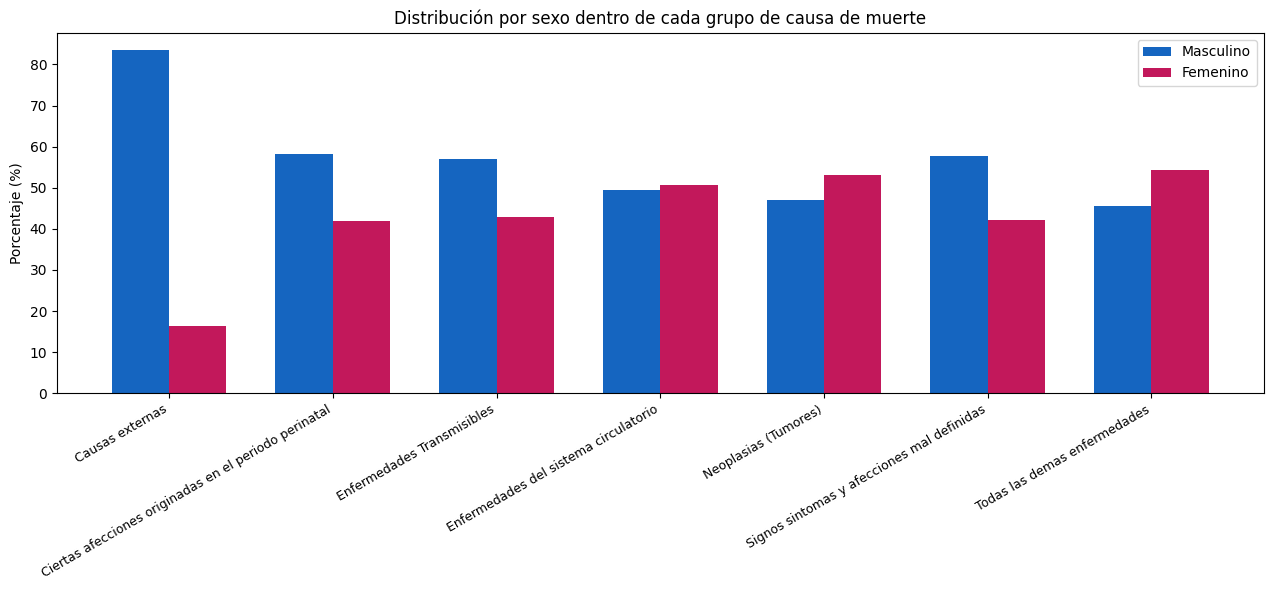

Conteos absolutos:
SEXO                                                Femenino  Indeterminado  \
NOM_667_OPS_GRUPO                                                             
Causas externas                                         2383              1   
Ciertas afecciones originadas en el periodo per...       469              0   
Enfermedades Transmisibles                              8190              0   
Enfermedades del sistema circulatorio                  20935              0   
Neoplasias (Tumores)                                   18489              0   
Signos sintomas y afecciones mal definidas               314              1   
Todas las demas enfermedades                           18370              1   

SEXO                                                Masculino  
NOM_667_OPS_GRUPO                                              
Causas externas                                         12078  
Ciertas afecciones originadas en el periodo per...        652  
Enfermedades 

In [568]:
# Tabla de proporciones
ct_sexo = pd.crosstab(
    df_clean["NOM_667_OPS_GRUPO"],
    df_clean["SEXO"],
    normalize="index"
) * 100

ct_sexo_counts = pd.crosstab(
    df_clean["NOM_667_OPS_GRUPO"],
    df_clean["SEXO"]
)

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(ct_sexo))
width = 0.35

bars_m = ax.bar(x, ct_sexo["Masculino"], width, label="Masculino", color="#1565C0")
bars_f = ax.bar(x + width, ct_sexo["Femenino"], width, label="Femenino", color="#C2185B")

# Etiquetas
ax.set_xticks(x + width / 2)
ax.set_xticklabels(ct_sexo.index, rotation=30, ha="right", fontsize=9)

ax.set_ylabel("Porcentaje (%)")
ax.set_title("Distribución por sexo dentro de cada grupo de causa de muerte")
ax.legend()

plt.tight_layout()
plt.show()

print("Conteos absolutos:")
print(ct_sexo_counts)

A partir del cruce entre el grupo de causa de muerte y el sexo, se observan diferencias importantes:

- En **causas externas**, la proporción de hombres es considerablemente mayor que la de mujeres. Esto puede estar relacionado con una mayor exposición de la población masculina a situaciones de riesgo como accidentes o violencia.

- En **enfermedades transmisibles**, también se observa una mayor participación de hombres, aunque la diferencia no es tan marcada como en causas externas.

- En **enfermedades del sistema circulatorio** y **neoplasias**, la distribución entre hombres y mujeres es más equilibrada, lo que sugiere que estas causas afectan de manera similar a ambos sexos.

- En general, la variable sexo sí muestra diferencias relevantes dependiendo del tipo de causa de muerte, por lo que resulta útil para el análisis y para futuras visualizaciones en el dashboard.

Estos resultados permiten identificar patrones diferenciados por sexo que pueden ser útiles en el análisis de salud pública.

### 5.2 Grupo OPS × Grupo etario

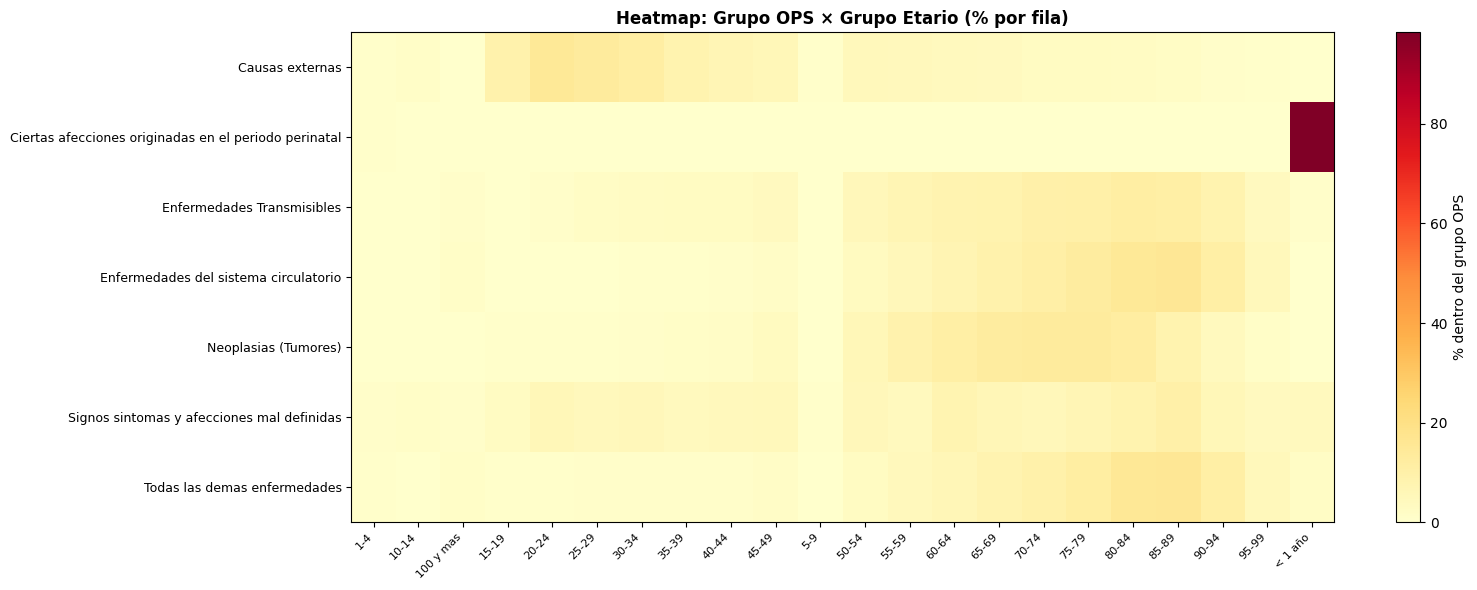

In [569]:
# ¿Qué edades concentra cada causa de muerte?
df_edad_ops = df_clean[
    df_clean["ETAREO_QUIN"].notna() & 
    ~df_clean["ETAREO_QUIN"].isin(["Sin informacion", "sin informacion"])
].copy()

heatmap_data = pd.crosstab(
    df_edad_ops["NOM_667_OPS_GRUPO"],
    df_edad_ops["ETAREO_QUIN"],
    normalize="index"
).round(3) * 100

# Ordenar columnas etarias si es posible
heatmap_data = heatmap_data.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="% dentro del grupo OPS")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title("Heatmap: Grupo OPS × Grupo Etario (% por fila)", fontweight="bold")
plt.tight_layout()
plt.show()

A partir del mapa de calor, se pueden identificar varios patrones relevantes:

- En el grupo de **menores de 1 año**, la totalidad de los casos se concentra en **afecciones originadas en el periodo perinatal**, lo cual es consistente con la naturaleza de este tipo de causas.

- En los grupos de edad entre **15 y 49 años**, se observa un leve aumento en la proporción de **causas externas**, lo que sugiere una mayor incidencia de muertes asociadas a accidentes o violencia en población joven y adulta.

- A partir de los **50 años y hasta aproximadamente los 94 años**, se evidencia una mayor concentración de defunciones en la mayoría de los grupos de causas, especialmente en enfermedades crónicas. Esto indica que la mortalidad en edades avanzadas está más asociada a enfermedades del sistema circulatorio, neoplasias y otras condiciones de salud.

- En general, fuera de estos patrones específicos, la distribución de los grupos etarios dentro de cada causa de muerte no presenta concentraciones extremadamente altas (en su mayoría por debajo del 30%), lo que indica que muchas causas afectan a distintos grupos de edad, aunque con mayor intensidad en edades adultas mayores.

En conjunto, estos resultados muestran que la edad es un factor clave en la distribución de las causas de muerte, diferenciando claramente entre mortalidad temprana, causas externas en población joven y enfermedades crónicas en edades avanzadas.

### Grupo OPS × Año

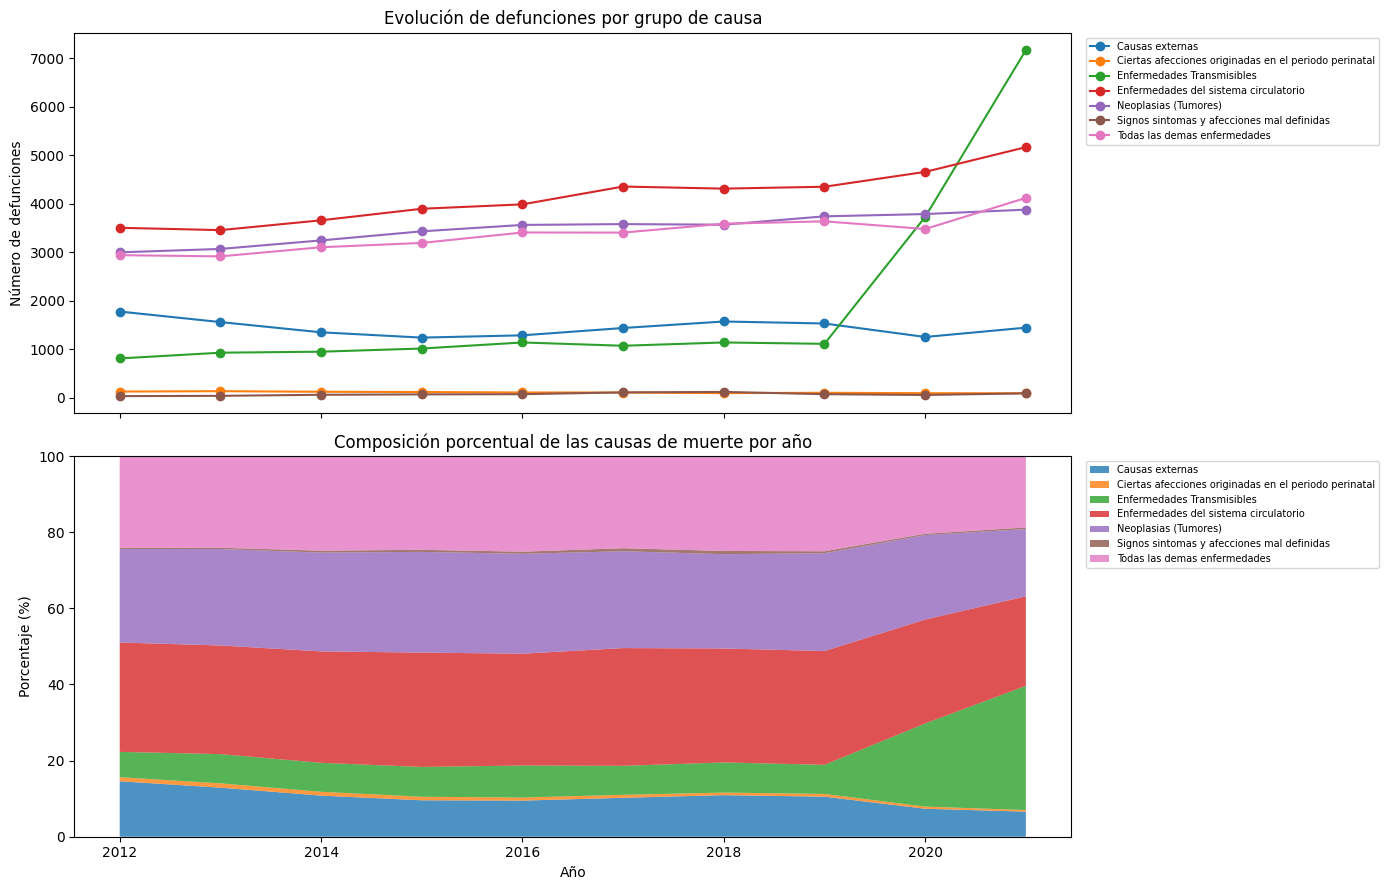

In [570]:
evol_ops = df_clean.groupby(["ANO", "NOM_667_OPS_GRUPO"]).size().unstack(fill_value=0)
evol_ops_pct = evol_ops.div(evol_ops.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Evolución absoluta
for col in evol_ops.columns:
    ax1.plot(evol_ops.index, evol_ops[col], marker="o", linewidth=1.5, label=col)

ax1.set_ylabel("Número de defunciones")
ax1.set_title("Evolución de defunciones por grupo de causa")
ax1.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")

# Evolución proporcional
ax2.stackplot(evol_ops_pct.index, evol_ops_pct.T.values, labels=evol_ops_pct.columns, alpha=0.8)

ax2.set_ylabel("Porcentaje (%)")
ax2.set_xlabel("Año")
ax2.set_title("Composición porcentual de las causas de muerte por año")
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

En la evolución temporal de las causas de muerte se observan patrones importantes:

- En términos absolutos, las principales causas de muerte mantienen una tendencia relativamente estable a lo largo del tiempo, sin cambios drásticos en la mayoría de los grupos.

- Sin embargo, se destaca un aumento notable alrededor del año 2019 en el grupo de **enfermedades transmisibles**, lo cual podría estar asociado a eventos específicos que incrementaron este tipo de defunciones.

- En la composición porcentual, las **enfermedades transmisibles** muestran un incremento marcado en ese mismo periodo, evidenciando un cambio temporal en la estructura de las causas de muerte.

- De forma general, también se observa un leve aumento en la participación de otros grupos de causas, mientras que las **causas externas** presentan una ligera disminución en su proporción relativa.

- A pesar de estas variaciones, las enfermedades del sistema circulatorio y las neoplasias continúan representando una parte importante del total de defunciones a lo largo de todos los años.

En conjunto, estos resultados indican que, aunque la estructura general de la mortalidad se mantiene relativamente estable, existen cambios puntuales en el tiempo que pueden ser relevantes para el análisis.

### Grupo OPS × Régimen de seguridad social

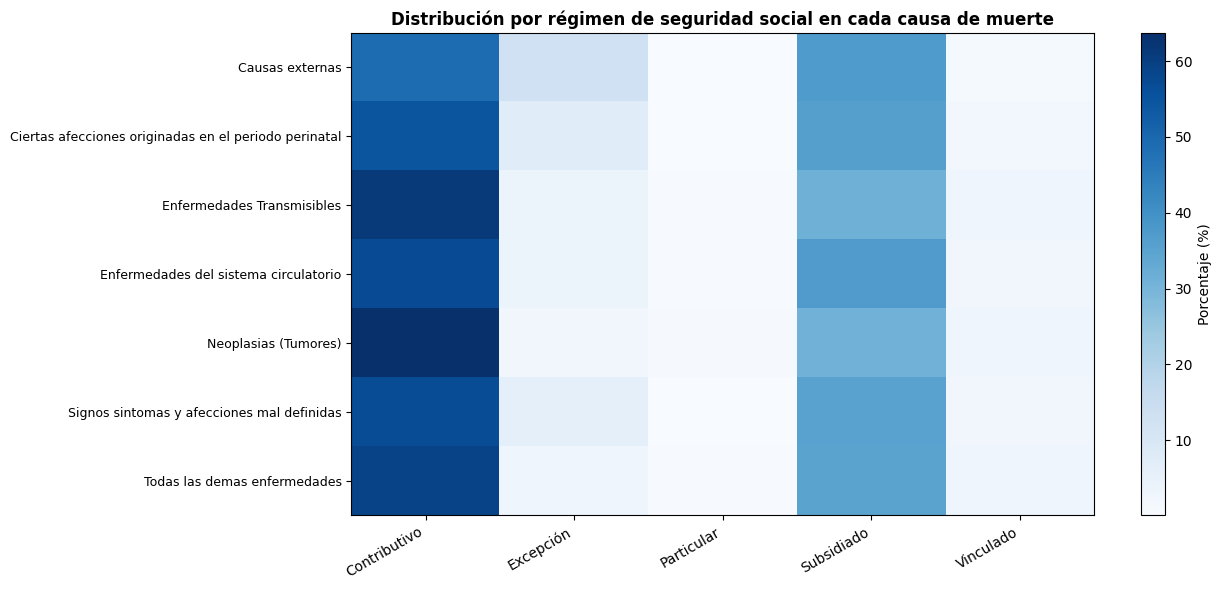

In [571]:
df_seg = df_clean[df_clean["SEG_SOCIAL"] != "Sin info"].copy()

ct_seg = pd.crosstab(
    df_seg["NOM_667_OPS_GRUPO"],
    df_seg["SEG_SOCIAL"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(ct_seg.values, aspect="auto", cmap="Blues")
plt.colorbar(im, ax=ax, label="Porcentaje (%)")

ax.set_xticks(range(len(ct_seg.columns)))
ax.set_xticklabels(ct_seg.columns, rotation=30, ha="right")
ax.set_yticks(range(len(ct_seg.index)))
ax.set_yticklabels(ct_seg.index, fontsize=9)

ax.set_title("Distribución por régimen de seguridad social en cada causa de muerte",fontweight="bold")

plt.tight_layout()
plt.show()

El análisis muestra una fuerte concentración de los casos en el régimen contributivo:

- En todos los grupos de causas de muerte, el **régimen contributivo** presenta la mayor proporción, alcanzando valores cercanos al 60%, lo que indica que la mayoría de los registros corresponde a población afiliada a este régimen.

- El **régimen subsidiado** también tiene una participación importante, aunque menor, ubicándose aproximadamente entre el 30% y 40% según el grupo de causa de muerte.

- El régimen de **excepción** presenta una proporción baja, generalmente entre el 10% y 15%, con una presencia mucho menor en comparación con los dos principales regímenes.

- Por otro lado, los regímenes **particular** y **vinculado** prácticamente no tienen representación en los datos, lo que sugiere que su impacto en este dataset es mínimo.

En general, no se observan diferencias marcadas entre los grupos de causas de muerte en función del régimen de seguridad social, sino más bien una distribución bastante homogénea dominada por el régimen contributivo.

Esto sugiere que, en este caso, el régimen de afiliación no parece ser un factor determinante fuerte en la diferenciación de las causas de muerte.

### Grupo OPS × Nivel educativo

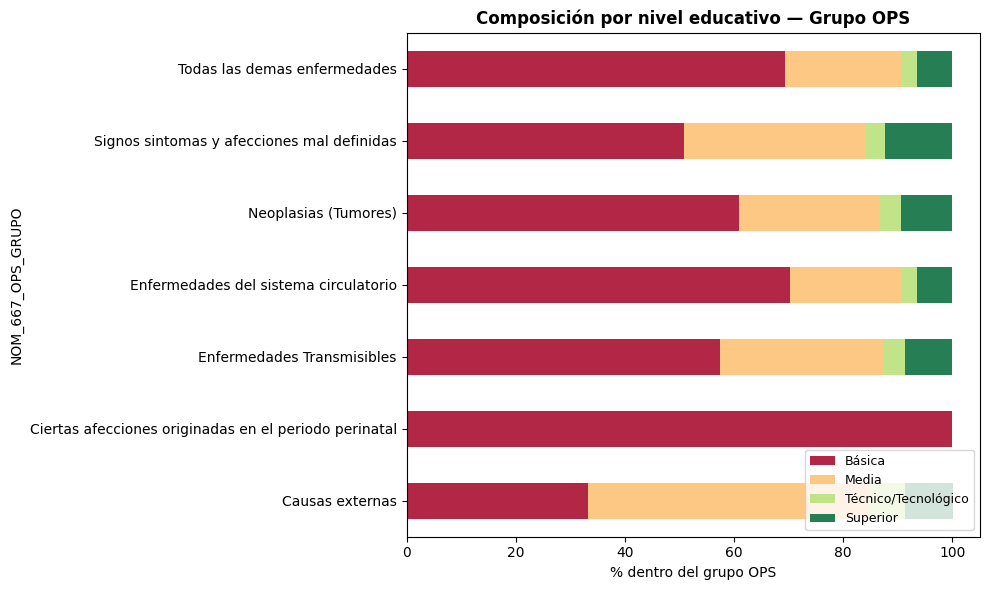

In [572]:
df_edu = df_clean[~df_clean["NIVEL_EDU_GRUPO"].isin(["Sin info"])].copy()

ct_edu = pd.crosstab(df_edu["NOM_667_OPS_GRUPO"], df_edu["NIVEL_EDU_GRUPO"], normalize="index").round(3)*100

orden_edu = ["Básica", "Media", "Técnico/Tecnológico", "Superior"]
ct_edu = ct_edu[[c for c in orden_edu if c in ct_edu.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
ct_edu.plot(kind="barh", ax=ax, stacked=True, colormap="RdYlGn", alpha=0.85)
ax.set_xlabel("% dentro del grupo OPS")
ax.set_title("Composición por nivel educativo — Grupo OPS", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [573]:
# Ver tabla ordenada 
print("Distribución porcentual por nivel educativo:")
print(ct_edu.round(1).to_string())

# Ver dominante por grupo OPS
dominante = ct_edu.idxmax(axis=1)
print("\nNivel educativo dominante por grupo OPS:")
print(dominante)

# Ver proporciones máximas
max_vals = ct_edu.max(axis=1).round(1)
print("\nPorcentaje del nivel educativo dominante:")
print(max_vals)

Distribución porcentual por nivel educativo:
NIVEL_EDU_GRUPO                                        Básica  Media  Técnico/Tecnológico  Superior
NOM_667_OPS_GRUPO                                                                                  
Causas externas                                         33.30  51.40                 6.60      8.80
Ciertas afecciones originadas en el periodo perinatal  100.00   0.00                 0.00      0.00
Enfermedades Transmisibles                              57.50  29.90                 4.00      8.50
Enfermedades del sistema circulatorio                   70.30  20.50                 2.80      6.40
Neoplasias (Tumores)                                    61.00  25.70                 4.00      9.30
Signos sintomas y afecciones mal definidas              50.90  33.30                 3.50     12.30
Todas las demas enfermedades                            69.40  21.30                 2.90      6.30

Nivel educativo dominante por grupo OPS:
NOM_667_OPS_G

En la relación entre el grupo de causas de muerte y el nivel educativo, se observa un patrón general claro.

En la mayoría de los grupos OPS predomina el nivel educativo básico, lo que indica que una gran parte de las defunciones se concentra en personas con menor nivel de formación. Este patrón es especialmente marcado en enfermedades del sistema circulatorio y otras enfermedades, donde supera el 65%.

Sin embargo, en el caso de las causas externas, se observa un comportamiento diferente, ya que el nivel educativo medio es el más frecuente, lo que sugiere un perfil distinto para este tipo de eventos.

Los niveles técnico/tecnológico y superior tienen una participación menor en todos los grupos, sin diferencias muy marcadas entre causas.

En general, el nivel educativo permite caracterizar el contexto socioeconómico de la población, aunque no actúa como un factor fuertemente diferenciador entre la mayoría de los grupos de causas de muerte.

### Grupo OPS × Comuna de residencia

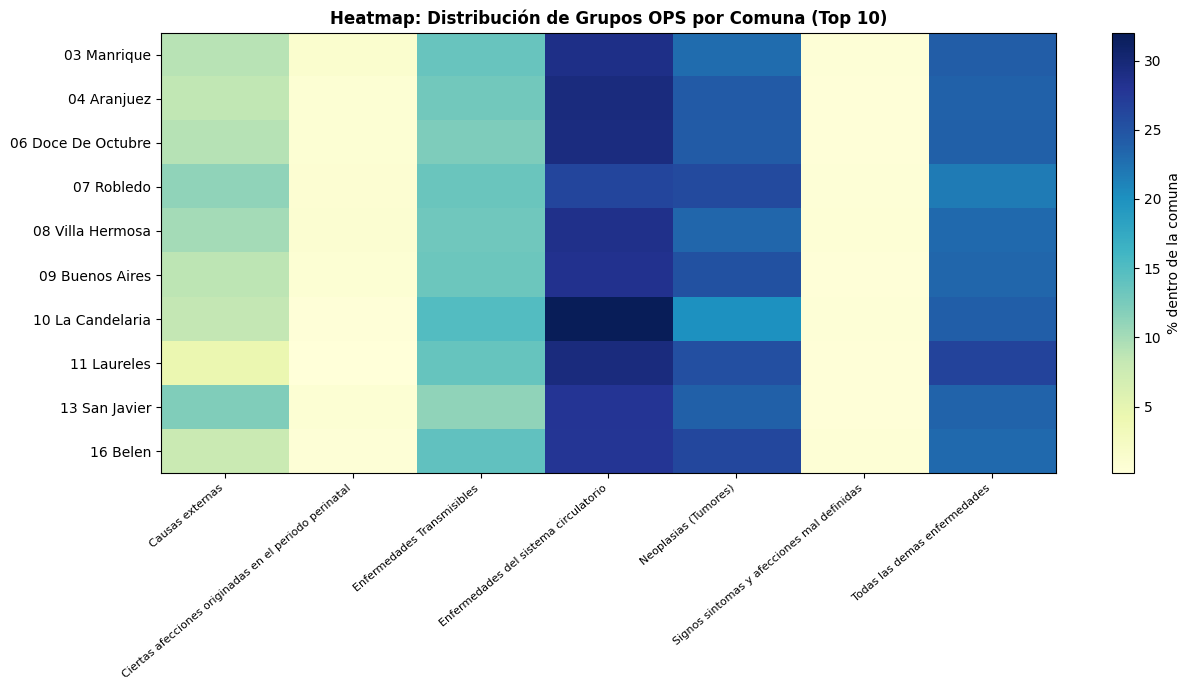

In [574]:
# Top 10 comunas vs distribución de causas
df_com = df_clean[~df_clean["COMUNA_RES"].isin(["Sin informacion", "sin informacion", np.nan])].dropna(subset=["COMUNA_RES"])

top10_comunas = df_com["COMUNA_RES"].value_counts().head(10).index
df_top_com = df_com[df_com["COMUNA_RES"].isin(top10_comunas)]

ct_com = pd.crosstab(df_top_com["COMUNA_RES"], df_top_com["NOM_667_OPS_GRUPO"], normalize="index").round(3)*100

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(ct_com.values, aspect="auto", cmap="YlGnBu")
plt.colorbar(im, ax=ax, label="% dentro de la comuna")
ax.set_xticks(range(len(ct_com.columns)))
ax.set_xticklabels(ct_com.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(ct_com.index)))
ax.set_yticklabels(ct_com.index)
ax.set_title("Heatmap: Distribución de Grupos OPS por Comuna (Top 10)", fontweight="bold")
plt.tight_layout()
plt.show()

In [575]:
# Tabla
print("Distribución porcentual por comuna (Top 10):")
print(ct_com.round(1).to_string())

# Grupo OPS dominante por comuna
dominante_com = ct_com.idxmax(axis=1)
print("\nGrupo OPS dominante por comuna:")
print(dominante_com)

# Qué tan dominante es
max_vals_com = ct_com.max(axis=1).round(1)
print("\nPorcentaje del grupo dominante por comuna:")
print(max_vals_com)

Distribución porcentual por comuna (Top 10):
NOM_667_OPS_GRUPO   Causas externas  Ciertas afecciones originadas en el periodo perinatal  Enfermedades Transmisibles  Enfermedades del sistema circulatorio  Neoplasias (Tumores)  Signos sintomas y afecciones mal definidas  Todas las demas enfermedades
COMUNA_RES                                                                                                                                                                                                                                                   
03 Manrique                    8.90                                                   1.20                       13.50                                  28.80                 22.90                                        0.50                         24.10
04 Aranjuez                    8.50                                                   0.80                       12.90                                  29.40                 24.30              

En el análisis entre el grupo de causas de muerte y la comuna de residencia (Top 10), se observa un patrón bastante homogéneo entre las diferentes zonas.

En todas las comunas analizadas, el grupo dominante corresponde a las enfermedades del sistema circulatorio, con proporciones que oscilan aproximadamente entre el 26% y el 32%. Esto indica que este tipo de causa de muerte es consistente en todo el territorio urbano, sin depender fuertemente de la ubicación geográfica.

Las neoplasias (tumores) y el grupo de "todas las demás enfermedades" también presentan participaciones importantes y relativamente estables entre comunas, lo que refuerza la idea de una estructura de mortalidad similar en la ciudad.

Por otro lado, las causas externas muestran una mayor variabilidad entre comunas, alcanzando valores más altos en zonas como San Javier y Robledo, lo que podría sugerir diferencias en factores de riesgo asociados a este tipo de eventos.

En general, aunque existen pequeñas variaciones porcentuales, no se evidencian diferencias territoriales marcadas en la distribución de las causas de muerte, lo que sugiere que el perfil de mortalidad es bastante uniforme entre las principales comunas del dataset.

---

## Dataset final

In [576]:
# Variables finales para dashboard
FEATURES_DASHBOARD = [
    "NOM_667_OPS_GRUPO",   # Variable objetivo
    "ANO", "MES",          # Temporales
    "SEXO",                # Demográfica
    "EDAD_SIMPLE",         # Demográfica (numérica)
    "ETAREO_QUIN",         # Demográfica (categórica)
    "EST_CIVIL",           # Demográfica
    "SEG_SOCIAL",          # Socioeconómica
    "NIVEL_EDU_GRUPO",     # Socioeconómica
    "COMUNA_RES",          # Geográfica
    "BARRIO_RES",          # Geográfica (mapas)
]

df_final = df_clean[FEATURES_DASHBOARD].copy()

print(f"Dataset final: {df_final.shape[0]:,} registros × {df_final.shape[1]} variables")
print(f"\nColumnas: {list(df_final.columns)}")

print("\nBalance de clases:")
print(df_final["NOM_667_OPS_GRUPO"].value_counts())

# Exportar
df_final.to_csv("defunciones_clean.csv", index=False, encoding="utf-8")

print("\n✓ Dataset exportado correctamente")

Dataset final: 145,377 registros × 11 variables

Columnas: ['NOM_667_OPS_GRUPO', 'ANO', 'MES', 'SEXO', 'EDAD_SIMPLE', 'ETAREO_QUIN', 'EST_CIVIL', 'SEG_SOCIAL', 'NIVEL_EDU_GRUPO', 'COMUNA_RES', 'BARRIO_RES']

Balance de clases:
NOM_667_OPS_GRUPO
Enfermedades del sistema circulatorio                    41337
Neoplasias (Tumores)                                     34857
Todas las demas enfermedades                             33785
Enfermedades Transmisibles                               19070
Causas externas                                          14462
Ciertas afecciones originadas en el periodo perinatal     1121
Signos sintomas y afecciones mal definidas                 745
Name: count, dtype: int64

✓ Dataset exportado correctamente


Luego del proceso de limpieza y selección de variables, se obtiene un dataset final compuesto por variables relevantes para el análisis y la construcción del dashboard.

Se excluyen variables que no aportan información significativa o que presentan redundancia, con el objetivo de trabajar con un conjunto de datos más claro y enfocado.

El dataset final incluye variables temporales, demográficas, socioeconómicas y geográficas, lo que permite analizar las defunciones desde diferentes perspectivas.

En particular, se destaca el uso de la variable EDAD_SIMPLE como medida principal de edad, ya que presenta valores consistentes y directamente interpretables.

Este dataset se encuentra listo para ser utilizado en la construcción de visualizaciones interactivas, facilitando la exploración de patrones y la comunicación de los hallazgos obtenidos.

---

## Conclusiones y hallazgos

El análisis exploratorio de datos permitió caracterizar el comportamiento de la mortalidad a partir de diferentes dimensiones: temporal, demográfica, socioeconómica y geográfica.

Desde la perspectiva temporal, se observa un comportamiento relativamente estable en los años previos, con un cambio notable en 2020 asociado al aumento de las enfermedades transmisibles, lo que evidencia la influencia de factores externos en la dinámica de la mortalidad.

En el ámbito demográfico, se identifican diferencias importantes por sexo y edad. En particular, las causas externas presentan una mayor proporción en hombres, especialmente en edades jóvenes, mientras que las enfermedades del sistema circulatorio y las neoplasias se concentran en edades más avanzadas, confirmando la relevancia de la edad como variable explicativa.

En cuanto a las causas de muerte, se evidencia una fuerte concentración en tres grupos principales: enfermedades del sistema circulatorio, neoplasias y otras enfermedades, lo que define la estructura general del fenómeno analizado.

Desde la perspectiva socioeconómica, variables como el nivel educativo y el régimen de seguridad social aportan contexto sobre la población, aunque no generan diferencias marcadas entre los grupos de causas de muerte.

A nivel geográfico, la distribución de las causas de muerte es bastante homogénea entre las principales comunas, sin evidenciar patrones territoriales fuertes.

En conjunto, estos resultados permiten comprender la estructura del dataset y constituyen una base sólida para la construcción del dashboard, facilitando la exploración interactiva y la comunicación de los patrones identificados.